# Nama: Taqiyuddin Ja'far
## NIM: 250401020186
### Kelas: IF405

## Langkah 1: Generate & Eksplorasi Dataset

Shape: (300, 4)
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


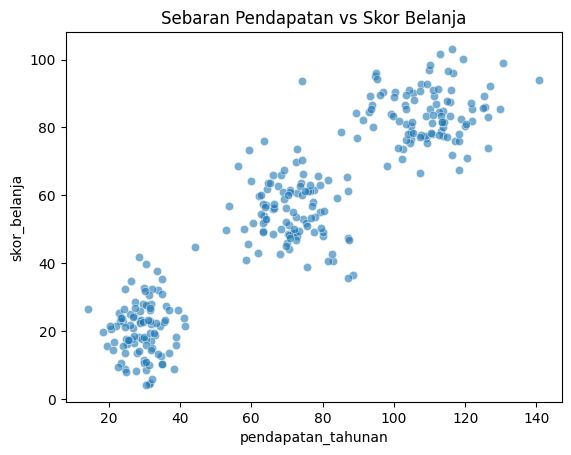

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

# Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
np.random.seed(42)
grp1 = np.random.normal([30, 20], [6, 8], (100, 2)) # hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2)) # menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2)) # boros
data = np.vstack([grp1, grp2, grp3])

df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

print('Shape:', df.shape)
print(df.describe().round(2))

# Bagian ini melakukan EDA singkat dengan visualisasi scatter plot.
sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6)
plt.title('Sebaran Pendapatan vs Skor Belanja')
plt.show()

### Catatan
- Dataset terdiri dari **300 data pelanggan**.
- Rata-rata pendapatan tahunan berada di angka **69.96** dengan skor belanja rata-rata **53.23**.
- Visualisasi scatter plot menunjukkan adanya **tiga kelompok (cluster) yang terpisah secara visual**, yang mengonfirmasi struktur dataset sintetis yang kita buat.

## Langkah 2: Preprocessing Data

In [3]:
from sklearn.preprocessing import StandardScaler

# Pilih fitur numerik yang relevan
X = df[['pendapatan_tahunan', 'skor_belanja']].values

# Terapkan StandardScaler agar setiap fitur memiliki skala yang setara
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Rata-rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std setelah scaling :', X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling: [-0.  0.]
Std setelah scaling : [1. 1.]


### Catatan
Setelah dilakukan *Standard Scaling*:
- Rata-rata fitur menjadi **0** dan standar deviasi menjadi **1**.
- Hal ini penting agar fitur dengan rentang nilai besar (seperti pendapatan) tidak mendominasi fitur dengan rentang kecil dalam perhitungan jarak K-Means.

## Langkah 3: Metode Elbow untuk Menentukan K

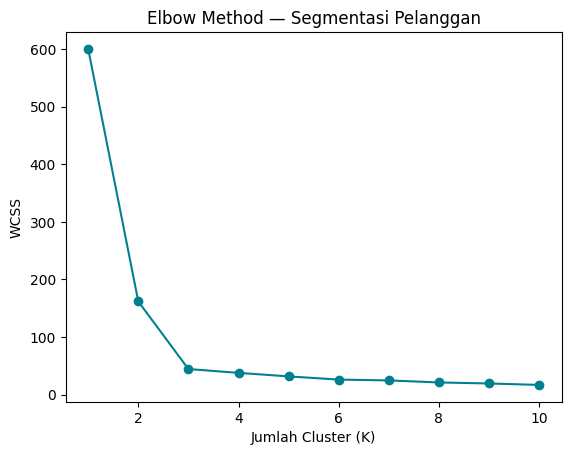

In [4]:
from sklearn.cluster import KMeans

# K-Means untuk K=1 hingga 10, simpan nilai WCSS setiap K
wcss = []
for k in range(1, 11):
  km = KMeans(n_clusters=k, random_state=42, init='k-means++')
  km.fit(X_scaled)
  wcss.append(km.inertia_)

# plot grafik Elbow
plt.plot(range(1, 11), wcss, marker='o', color='#028090')
plt.xlabel('Jumlah Cluster (K)'); plt.ylabel('WCSS')
plt.title('Elbow Method — Segmentasi Pelanggan')
plt.show()

# Interpretasikan dalam sel Markdown berikutnya:
# - Di K berapa kurva mulai melandai (titik elbow)?
# - Apakah hasilnya sesuai dengan jumlah kelompok yang diharapkan?

### Interpretasi Metode Elbow
- Grafik menunjukkan penurunan tajam WCSS dari K=1 ke K=3.
- Setelah **K=3**, penurunan WCSS mulai melandai (membentuk siku atau *elbow*).
- Oleh karena itu, jumlah cluster optimal yang dipilih adalah **K=3**.

## Langkah 4: Melatih Model K-Means

In [5]:
from sklearn.metrics import silhouette_score

# Latih model K-Means dengan K optimal hasil pengamatan grafik Elbow
model = KMeans(n_clusters=3, random_state=42, init='k-means++')
model.fit(X_scaled)
df['cluster'] = model.labels_

# menampilkan koefisien evaluasinya
print(f'WCSS akhir : {model.inertia_:.3f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, model.labels_):.3f}')
print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2))

WCSS akhir : 44.556
Silhouette Score: 0.695
         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.99         55.05
1                     29.31         20.27
2                    109.20         84.08


### Interpretasi Evaluasi Model
- **Silhouette Score (0.695)**: Nilai yang mendekati 0.7 menunjukkan bahwa struktur clustering sangat kuat dan antar kelompok terpisah dengan baik.
- **Profil Cluster**:
    - **Cluster 0**: Pendapatan Menengah (~ 71), Belanja Menengah (~55).
    - **Cluster 1**: Pendapatan Rendah (~ 29), Belanja Rendah (~20).
    - **Cluster 2**: Pendapatan Tinggi (~ 109), Belanja Tinggi (~84).

## Langkah 5: Visualisasi Hasil Clustering

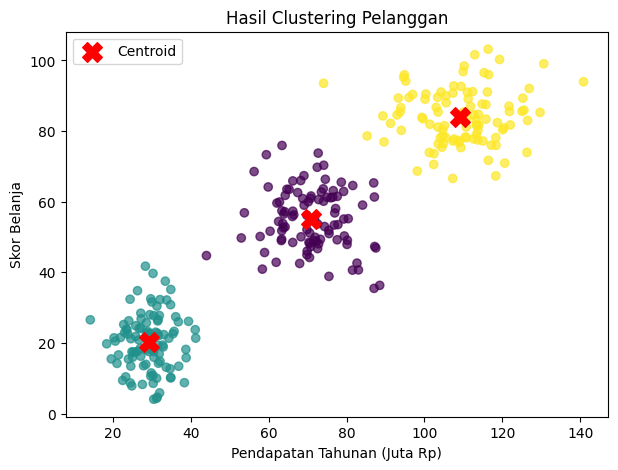

In [7]:
centroids = scaler.inverse_transform(model.cluster_centers_)

# scatter plot berwarna per cluster beserta posisi centroid
plt.figure(figsize=(7, 5))
plt.scatter(df['pendapatan_tahunan'], df['skor_belanja'],
            c=df['cluster'], cmap='viridis', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', marker='X', s=200, label='Centroid')
plt.xlabel('Pendapatan Tahunan (Juta Rp)');
plt.ylabel('Skor Belanja')
plt.title('Hasil Clustering Pelanggan')
plt.legend()
plt.show()

### Visualisasi Akhir K-Means
- Scatter plot menunjukkan pembagian area yang sangat jelas untuk ketiga segmen.
- Titik silang merah (**Centroid**) berada tepat di tengah-tengah konsentrasi data tiap kelompok, menandakan model telah konvergen dengan baik.

### Interpretasi Segmen Pelanggan

Berdasarkan hasil rata-rata fitur pada tiap cluster, kita dapat mengidentifikasi karakteristik segmen sebagai berikut:

1.  **Cluster 0 - Segmen 'Menengah'**:
    *   **Karakteristik**: Pendapatan tahunan sedang (~ 71) dan skor belanja sedang (~55).
    *   **Strategi**: Pertahankan loyalitas dengan program reward standar.

2.  **Cluster 1 - Segmen 'Hemat'**:
    *   **Karakteristik**: Pendapatan tahunan rendah (~ 29) dan skor belanja rendah (~20).
    *   **Strategi**: Berikan promosi berbasis nilai atau diskon untuk meningkatkan daya tarik belanja.

3.  **Cluster 2 - Segmen 'Boros / Premium'**:
    *   **Karakteristik**: Pendapatan tahunan tinggi (~ 109) dan skor belanja tinggi (~84).
    *   **Strategi**: Target utama untuk kampanye produk eksklusif dan layanan prioritas.

## Langkah 6: Hierarchical Clustering (Pembanding)

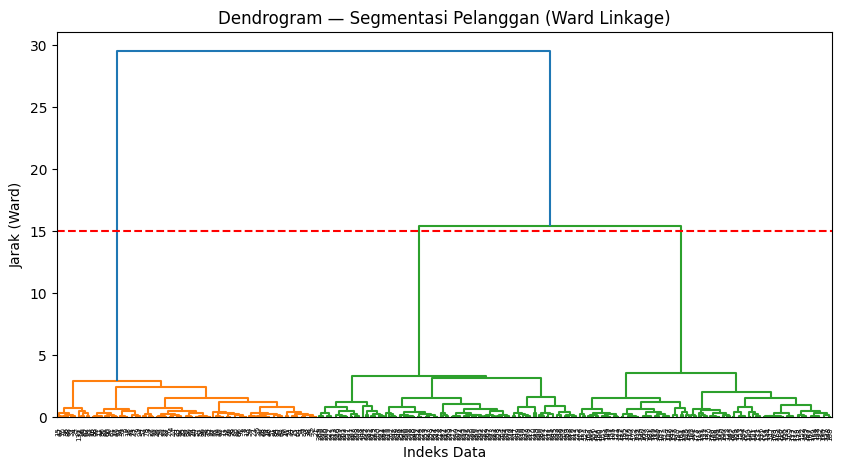

In [8]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Sebagai pembanding, bangun dendrogram menggunakan Ward linkage
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Dendrogram — Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Indeks Data'); plt.ylabel('Jarak (Ward)')
plt.axhline(y=15, color='red', linestyle='--') # contoh garis potong
plt.show()

# Bandingkan: apakah jumlah cluster dari dendrogram (garis potong)
# konsisten dengan K optimal hasil Metode Elbow pada Langkah 3?

### Interpretasi Hierarchical Clustering
- Dendrogram menunjukkan tiga cabang utama yang memiliki jarak *linkage* yang cukup jauh sebelum bergabung.
- Garis potong merah pada jarak 15 menghasilkan **3 cluster**, yang **konsisten** dengan hasil metode Elbow pada K-Means.
- Hal ini memvalidasi bahwa struktur data alami memang terdiri dari 3 kelompok.

## Kesimpulan Akhir

### Apa yang Dipelajari
Melalui praktikum ini, saya mempelajari alur kerja *Unsupervised Learning* yang lengkap, mulai dari pembuatan dataset sintetis, normalisasi data dengan `StandardScaler`, penentuan jumlah cluster optimal menggunakan **Metode Elbow**, hingga validasi hasil menggunakan **Silhouette Score** dan **Hierarchical Clustering (Dendrogram)**.

### Temuan Utama
1.  **Konsistensi Model**: Baik Metode Elbow maupun Dendrogram secara konsisten menunjukkan bahwa **K=3** adalah jumlah cluster paling optimal untuk dataset ini.
2.  **Kualitas Segmentasi**: Skor Silhouette sebesar **0.695** menunjukkan pemisahan antar cluster yang sangat baik dan struktur data yang solid.
3.  **Profil Pelanggan**: Kita berhasil mengidentifikasi tiga kelompok perilaku ekonomi yang jelas: pelanggan **Hemat** (pendapatan & belanja rendah), **Menengah**, dan **Premium** (pendapatan & belanja tinggi).

### Keterbatasan & Pertanyaan Lanjutan
- **Keterbatasan Data**: Analisis ini hanya menggunakan dua fitur utama (pendapatan dan skor belanja). Penambahan fitur lain seperti 'usia' atau 'gender' mungkin akan memberikan wawasan segmentasi yang lebih mendalam.
- **Keterbatasan Algoritma**: K-Means sangat sensitif terhadap *outlier*. Meskipun tidak ditemukan masalah pada data sintetis ini, pada data dunia nyata, langkah pembersihan *outlier* akan sangat krusial.
- **Pertanyaan**: Bagaimana jika tren perilaku belanja berubah seiring waktu? Analisis ini bersifat statis dan mungkin memerlukan pemodelan ulang secara periodik.